초급 프로젝트 Model Architect 업무

**2026/09/11**
일단 200개 있는 학습 사진들으로 처음으로 모델을 한 번 돌려보는 것을 목적으로 하겠습니다.
일단, 객체 인식을 진행했던 스프린트 미션 7이 있어서 코드를 한 번 가져와서 바로 진행해보겠습니다.
돌려보고, mAP 점수 확인까지 진행하는 것으로 하겠습니다.

기본 모델은 제가 미션 7에서 활용했었던 VGGNet(전이학습) + SSD(1-stage Detector)입니다.
물론, 만족스러운 점수가 나오지는 않을텐데, 여기에서 나온 mAP 점수를 기준으로 해서 이 점수보다 낮게 나오는 경우 비정상적인 경우라고 판단할 수 있는 벤치마크로 활용하겠습니다.



In [ ]:
#@title Import Module
import os
import cv2
import csv
import glob
import json
import random
import kagglehub
import numpy as np
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import pandas as pd
import xml.etree.ElementTree as ET

import torch
import torchvision

from collections import defaultdict
from torchvision import tv_tensors
from torchvision.transforms import v2
from torchvision.transforms import functional as F
from torch.utils.data import Dataset, DataLoader
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torchvision.models.detection.ssd import SSD300_VGG16_Weights
from torchvision.models.detection.ssd import SSDClassificationHead
from torchvision.models.detection import _utils as det_utils
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score
from collections import defaultdict
from PIL import Image
from tqdm import tqdm

In [20]:
#@title Set Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
#@title Image, Annotation 경로 설정
path = kagglehub.competition_download("ai14-level-project")
path = os.path.join(path, "sprint_ai_project1_data")
print(path)

image_dir = glob.glob(os.path.join(path, "train_images", "*.png"))

annotation_dir = glob.glob(
    os.path.join(path, "train_annotations", "**", "*.json"),
    recursive=True
)

print(f"Train 이미지 수 : {len(image_dir)}, Annotation 수 : {len(annotation_dir)}")

Train 이미지 수 : 232, Annotation 수 : 763


In [22]:
#@title Image-Annotation Mapping

# Train 이미지에 해당하지 않는 Annotation 개수 확인
annotation_not_in_train_image = []
for image_path in image_dir:
    image_name = os.path.basename(image_path)
    annotation_name = image_name.replace(".png", ".json")
    if annotation_name not in [os.path.basename(annotation_path) for annotation_path in annotation_dir]:
        annotation_not_in_train_image.append(image_name)

print(f"Annotation에 해당하지 않는 Train 이미지 개수: {len(annotation_not_in_train_image)}")

# Annotation 에 없는 Train 이미지 개수 확인
train_image_not_in_annotation = []
for annotation_path in annotation_dir:
    annotation_name = os.path.basename(annotation_path)
    image_name = annotation_name.replace(".json", ".png")
    if image_name not in [os.path.basename(image_path) for image_path in image_dir]:
        train_image_not_in_annotation.append(annotation_name)

print(f"Train 이미지에 해당하지 않는 Annotation 개수: {len(train_image_not_in_annotation)}")

# Train 이미지와 Annotation 매핑 가능한 데이터 수
image_annotation_mapping = {}
for image_path in image_dir:
    image_name = os.path.basename(image_path)
    annotation_name = image_name.replace(".png", ".json")
    if annotation_name in [os.path.basename(annotation_path) for annotation_path in annotation_dir]:
        image_annotation_mapping[image_name] = annotation_name

print(f"Train 이미지와 Annotation 매핑 가능한 데이터 수: {len(image_annotation_mapping)}")

# Image - Annotation Mapping을 위한 코드
image_names = [os.path.basename(image_path) for image_path in image_dir]
annotation_names = [os.path.basename(annotation_path) for annotation_path in annotation_dir]

image_annotation_mapping_process = {}
for image_name in image_names:
    annotation_name = image_name.replace(".png", ".json")
    if annotation_name in annotation_names:
        image_annotation_mapping_process[image_name] = annotation_name


Annotation에 해당하지 않는 Train 이미지 개수: 0
Train 이미지에 해당하지 않는 Annotation 개수: 0
Train 이미지와 Annotation 매핑 가능한 데이터 수: 232


이상하다? Train 이미지는 232개인데, Annotation은 763개인데 Train 이미지에 해당하지 않는 Annotation의 개수가 0개라는게 말이 안된다고 생각했습니다.

그래서 중복되는 annotation이 있는지 확인하는게 다음 코드입니다.

In [23]:
#@title Annotation 경로 매핑 (중복 대응)
annotation_path_by_stem = {}
duplicate_mismatch = []

for ann_path in annotation_dir:
    stem = os.path.splitext(os.path.basename(ann_path))[0]
    if stem in annotation_path_by_stem:
        # 중복 파일이 내용까지 같은지 확인
        with open(annotation_path_by_stem[stem], "r", encoding="utf-8") as f1, open(ann_path, "r", encoding="utf-8") as f2:
            if f1.read() != f2.read():
                duplicate_mismatch.append(stem)
    else:
        annotation_path_by_stem[stem] = ann_path

print(f"고유 annotation stem 수: {len(annotation_path_by_stem)}")
print(f"내용이 다른 중복 파일 수: {len(duplicate_mismatch)}")
if duplicate_mismatch:
    print("확인 필요:", duplicate_mismatch[:10])

고유 annotation stem 수: 232
내용이 다른 중복 파일 수: 531
확인 필요: ['K-001900-016548-019607-029451_0_2_0_2_70_000_200', 'K-001900-016548-019607-029451_0_2_0_2_75_000_200', 'K-001900-016548-019607-029451_0_2_0_2_90_000_200', 'K-001900-016548-019607-029451_0_2_0_2_70_000_200', 'K-001900-016548-019607-029451_0_2_0_2_75_000_200', 'K-001900-016548-019607-029451_0_2_0_2_90_000_200', 'K-001900-016548-019607-029451_0_2_0_2_70_000_200', 'K-001900-016548-019607-029451_0_2_0_2_75_000_200', 'K-001900-016548-019607-029451_0_2_0_2_90_000_200', 'K-001900-016548-019607-033009_0_2_0_2_70_000_200']


In [24]:
#@title 중복 annotation 내용 진단
stem_to_paths = defaultdict(list)
for ann_path in annotation_dir:
    stem = os.path.splitext(os.path.basename(ann_path))[0]
    stem_to_paths[stem].append(ann_path)

# 확인 필요 목록 중 하나 골라서 상세 비교
sample_stem = "K-003351-016232-033880_0_2_0_2_75_000_200"
sample_paths = stem_to_paths[sample_stem]

print(f"'{sample_stem}' 관련 파일 개수: {len(sample_paths)}")
for p in sample_paths:
    with open(p, "r", encoding="utf-8") as f:
        data = json.load(f)
    ann_summaries = [(a["id"], a["category_id"], a["bbox"]) for a in data["annotations"]]
    cat_names = [c["name"] for c in data["categories"]]
    print("---")
    print("경로:", p)
    print("categories:", cat_names)
    print("annotations (id, category_id, bbox):", ann_summaries)

'K-003351-016232-033880_0_2_0_2_75_000_200' 관련 파일 개수: 3
---
경로: C:/Users/yiydg/Desktop/Vault_home/💼 Projects(Work)/Sprint AI_14기/workspace/프로젝트_초급/sprint_ai_project1_data\train_annotations\K-003351-016232-033880_json\K-003351\K-003351-016232-033880_0_2_0_2_75_000_200.json
categories: ['일양하이트린정 2mg']
annotations (id, category_id, bbox): [(56, 3351, [317, 186, 189, 188])]
---
경로: C:/Users/yiydg/Desktop/Vault_home/💼 Projects(Work)/Sprint AI_14기/workspace/프로젝트_초급/sprint_ai_project1_data\train_annotations\K-003351-016232-033880_json\K-016232\K-003351-016232-033880_0_2_0_2_75_000_200.json
categories: ['리피토정 20mg']
annotations (id, category_id, bbox): [(53, 16232, [605, 706, 197, 193])]
---
경로: C:/Users/yiydg/Desktop/Vault_home/💼 Projects(Work)/Sprint AI_14기/workspace/프로젝트_초급/sprint_ai_project1_data\train_annotations\K-003351-016232-033880_json\K-033880\K-003351-016232-033880_0_2_0_2_75_000_200.json
categories: ['글리틴정(콜린알포세레이트)']
annotations (id, category_id, bbox): [(50, 33880, [7, 682, 451,

In [ ]:
# 이미지 stem -> 이미지 경로
image_stem_to_path = {
    os.path.splitext(os.path.basename(image_path))[0]: image_path
    for image_path in image_dir
}

# 이미지 stem -> 여러 annotation JSON 경로
stem_to_paths = defaultdict(list)

for annotation_path in annotation_dir:
    stem = os.path.splitext(os.path.basename(annotation_path))[0]
    stem_to_paths[stem].append(annotation_path)

# 이미지와 annotation이 모두 존재하는 stem만 사용
valid_stems = [
    stem
    for stem in stem_to_paths
    if stem in image_stem_to_path
]

# 매핑되지 않는 데이터 확인
images_without_annotation = (
    set(image_stem_to_path) - set(stem_to_paths)
)

annotations_without_image = (
    set(stem_to_paths) - set(image_stem_to_path)
)

print(f"Annotation이 없는 Train 이미지 수: {len(images_without_annotation)}")
print(f"Train 이미지가 없는 Annotation stem 수: {len(annotations_without_image)}")
print(f"매핑 가능한 이미지 수: {len(valid_stems)}")

In [ ]:
#@title Annotation 경로 매핑 (stem -> 여러 파일)
avg_per_stem = sum(len(v) for v in stem_to_paths.values()) / len(stem_to_paths)

print(
    f"고유 이미지 수: {len(stem_to_paths)}, "
    f"이미지당 평균 annotation 파일 수: {avg_per_stem:.2f}"
)

고유 이미지 수: 232, 이미지당 평균 annotation 파일 수: 3.29


In [ ]:
#@title 이미지 단위 Annotation 병합

def build_image_records(valid_stems, stem_to_paths):
    image_records = {}
    category_id_to_name = {}

    for stem in valid_stems:
        img_info = None
        annotations = []

        for annotation_path in stem_to_paths[stem]:
            with open(annotation_path, "r", encoding="utf-8") as f:
                data = json.load(f)

            # 이미지 정보는 같은 stem의 JSON끼리 동일하므로 처음 한 번만 저장
            if img_info is None:
                img_info = data["images"][0]

            # 클래스 정보 저장
            for category in data["categories"]:
                category_id_to_name[category["id"]] = category["name"]

            # 같은 이미지에 속한 annotation들을 하나로 병합
            for ann in data["annotations"]:
                annotations.append({
                    "bbox": ann["bbox"],
                    "category_id": ann["category_id"],
                    "area": ann["area"],
                    "iscrowd": ann.get("iscrowd", 0)
                })

        image_records[stem] = {
            "file_name": img_info["file_name"],
            "width": img_info["width"],
            "height": img_info["height"],
            "annotations": annotations
        }

    return image_records, category_id_to_name


image_records, category_id_to_name = build_image_records(
    valid_stems,
    stem_to_paths
)

print(f"이미지 record 수: {len(image_records)}")
print(f"클래스 수: {len(category_id_to_name)}")

In [ ]:
#@title 이미지 해상도 파악
sizes = set()
for img_path in image_dir[:50]:  # 200장이면 전수 조사해도 됨: image_dir 전체로
    with Image.open(img_path) as im:
        sizes.add(im.size)  # (width, height)

print(f"고유 해상도 종류 수: {len(sizes)}")
print(sizes if len(sizes) < 10 else list(sizes)[:10])

Unique Image Shapes (1종류):
(1280, 976, 3)


In [27]:
#@title 폴더별 partial annotation 병합
def load_merged_annotation(paths):
    img_info = None
    boxes, labels, areas, iscrowd = [], [], [], []

    for p in paths:
        with open(p, "r", encoding="utf-8") as f:
            data = json.load(f)

        if img_info is None:
            img_info = data["images"][0]  # width/height/file_name은 모든 폴더에서 동일하다고 가정

        for ann in data["annotations"]:
            boxes.append(ann["bbox"])       # [x, y, w, h]
            labels.append(ann["category_id"])
            areas.append(ann["area"])
            iscrowd.append(ann.get("iscrowd", 0))

    return img_info, boxes, labels, areas, iscrowd

In [29]:
#@title Transformer
train_transformer = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(dtype=torch.float32, scale=True),
    v2.Resize((300, 300)),
])

val_test_transformer = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(dtype=torch.float32, scale=True),
    v2.Resize((300, 300)),
])

In [ ]:
#@title 클래스(category) 매핑 생성
sorted_ids = sorted(category_id_to_name.keys())

category_to_label = {
    cid: i + 1
    for i, cid in enumerate(sorted_ids)
}

label_to_category = {
    v: k
    for k, v in category_to_label.items()
}

classes = ["background"] + [
    category_id_to_name[cid]
    for cid in sorted_ids
]

num_classes = len(classes)

print(f"클래스 수(background 포함): {num_classes}")

클래스 수(background 포함): 57


In [ ]:
#@title Pill Dataset 정의

class PillDataset(Dataset):
    def __init__(
        self,
        image_dir,
        image_records,
        stems,
        category_to_label,
        transforms=None
    ):
        self.image_dir = image_dir
        self.image_records = image_records
        self.stems = stems
        self.category_to_label = category_to_label
        self.transforms = transforms

    def __len__(self):
        return len(self.stems)

    def __getitem__(self, idx):
        stem = self.stems[idx]

        # 미리 병합해둔 annotation 정보 가져오기
        record = self.image_records[stem]

        image = Image.open(
            os.path.join(self.image_dir, record["file_name"])
        ).convert("RGB")

        w = record["width"]
        h = record["height"]

        boxes = []
        labels = []
        areas = []
        iscrowd = []

        for ann in record["annotations"]:
            x, y, bw, bh = ann["bbox"]

            boxes.append([x, y, x + bw, y + bh])
            labels.append(
                self.category_to_label[ann["category_id"]]
            )
            areas.append(ann["area"])
            iscrowd.append(ann["iscrowd"])

        image = tv_tensors.Image(image)

        boxes = tv_tensors.BoundingBoxes(
            boxes,
            format="XYXY",
            canvas_size=(h, w)
        )

        target = {
            "boxes": boxes,
            "labels": torch.as_tensor(labels, dtype=torch.int64),
            "image_id": torch.tensor([idx]),
            "area": torch.as_tensor(areas, dtype=torch.float32),
            "iscrowd": torch.as_tensor(iscrowd, dtype=torch.int64),
        }

        if self.transforms:
            image, target = self.transforms(image, target)

        return image, target

In [ ]:
#@title Dataset ~ DataLoader
stems = list(stem_to_paths.keys())
train_stems, valid_stems = train_test_split(stems, test_size=0.2, random_state=42)

train_dataset = PillDataset(
    image_dir=os.path.join(path, "train_images"),
    image_records=image_records,
    stems=train_stems,
    category_to_label=category_to_label,
    transforms=train_transformer
)
valid_dataset = PillDataset(
    image_dir=os.path.join(path, "train_images"),
    image_records=image_records,
    stems=valid_stems,
    category_to_label=category_to_label,
    transforms=val_test_transformer
)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))
val_loader = DataLoader(valid_dataset, batch_size=8, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))

In [33]:
model = torchvision.models.detection.ssd300_vgg16(
    weights=SSD300_VGG16_Weights.DEFAULT,
    detections_per_img=4
).to(device)
in_channels = det_utils.retrieve_out_channels(model.backbone, (300, 300))
num_anchors = model.anchor_generator.num_anchors_per_location()
model.head.classification_head = SSDClassificationHead(in_channels, num_anchors, num_classes).to(device)

CHECKPOINT_PATH = "best_model_vgg16_ssd300.pth"

In [34]:
#@title Define Optimizer & Scheduler
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

In [35]:
#@title mAP 계산 함수 (IoU threshold 0.75~0.95)
iou_thresholds = [0.75, 0.80, 0.85, 0.90, 0.95]

def evaluate_map(model, data_loader, device):
    model.eval()
    metric = MeanAveragePrecision(iou_type="bbox", iou_thresholds=iou_thresholds)

    with torch.no_grad():
        for images, targets in tqdm(data_loader, desc="Evaluating"):
            images = [img.to(device) for img in images]
            preds = model(images)

            preds_cpu = [{k: v.cpu() for k, v in p.items()} for p in preds]
            targets_cpu = [{"boxes": t["boxes"].cpu(), "labels": t["labels"].cpu()} for t in targets]

            metric.update(preds_cpu, targets_cpu)

    result = metric.compute()
    model.train()
    return result

In [36]:
num_epochs = 30
best_map = -float("inf")

train_loss_hist = []
val_map_hist = []
val_map_75_hist = []

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0.0

    for images, targets in tqdm(train_loader, desc=f"Epoch {epoch + 1} Training"):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in target.items()} for target in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_train_loss += losses.item()

    lr_scheduler.step()
    avg_train_loss = total_train_loss / len(train_loader)

    val_map = evaluate_map(model, val_loader, device)
    current_map = val_map["map"].item()
    current_map_75 = val_map["map_75"].item()

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"mAP[.75:.95]: {current_map:.4f} | "
        f"mAP@75: {current_map_75:.4f}"
    )

    train_loss_hist.append(avg_train_loss)
    val_map_hist.append(current_map)
    val_map_75_hist.append(current_map_75)

    if current_map > best_map:
        best_map = current_map
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print(f"  → New best model saved (mAP: {best_map:.4f})")

# 학습 마지막 epoch 모델이 아니라, 검증 mAP가 가장 높았던 모델을 사용
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
model.to(device)
model.eval()

print(f"\n최종 사용할 최고 검증 mAP: {best_map:.4f}")

Evaluating: 100%|██████████| 6/6 [00:04<00:00,  1.40it/s]


Epoch 1/30 | Train Loss: 15.8479 | mAP[.75:.95]: 0.0148 | mAP@75: 0.0227
  → New best model saved (mAP: 0.0148)


Evaluating: 100%|██████████| 6/6 [00:03<00:00,  1.85it/s]


Epoch 2/30 | Train Loss: 8.6332 | mAP[.75:.95]: 0.0485 | mAP@75: 0.0711
  → New best model saved (mAP: 0.0485)


Evaluating: 100%|██████████| 6/6 [00:03<00:00,  1.93it/s]


...

Epoch 28/30 | Train Loss: 3.1893 | mAP[.75:.95]: 0.2673 | mAP@75: 0.3567


Evaluating: 100%|██████████| 6/6 [00:03<00:00,  1.87it/s]


Epoch 29/30 | Train Loss: 3.2247 | mAP[.75:.95]: 0.2673 | mAP@75: 0.3567


Evaluating: 100%|██████████| 6/6 [00:03<00:00,  1.89it/s]


Epoch 30/30 | Train Loss: 3.1903 | mAP[.75:.95]: 0.2673 | mAP@75: 0.3567

최종 사용할 최고 검증 mAP: 0.2688


개선할 수 있는 점
1. 박스의 개수에 제한을 하나도 걸지 않았음
- 모델을 개선하기 시작하는 경우, train / test 데이터에 알약이 3개 아니면 4개만 있다는 점을 확인하고, BoundingBox의 개수를 제한할 수 있음
2. 그냥 미션 7에서 활용한 VGGNet이랑 SSD 그대로 활용했음
- 사실 VGGNet에 SSD는 너무 오래된 전통적인 모델이라 다른 조합을 생각해볼 수 있음
- 다음의 조합도 다 실행해 봐야겠음

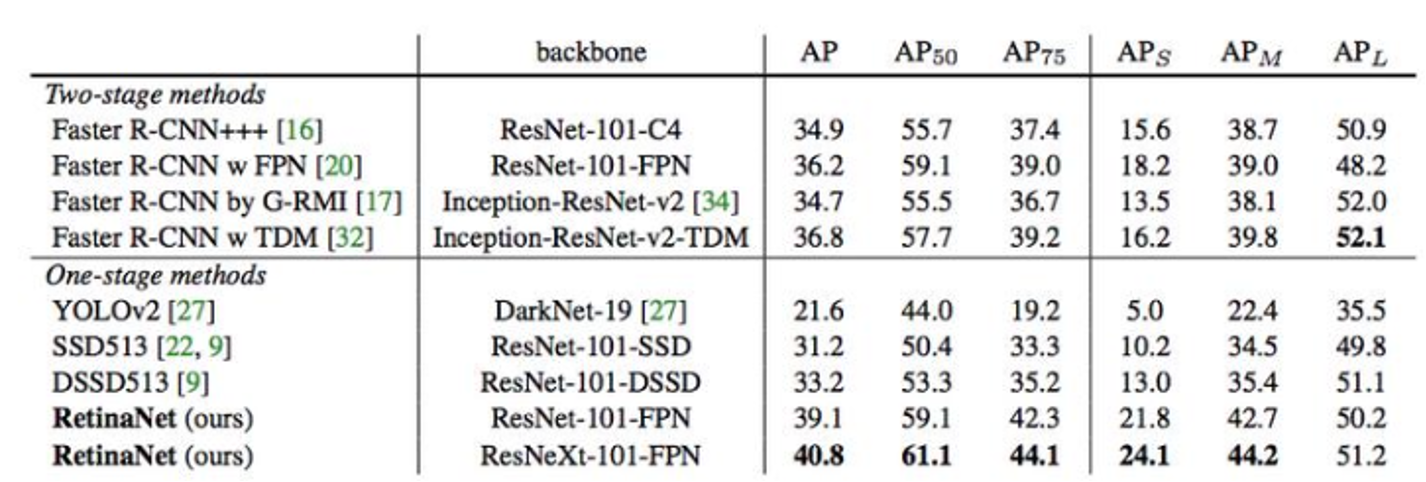

| Method | Backbone | AP | AP₅₀ | AP₇₅ | APₛ | APₘ | APₗ |
|---|---|---:|---:|---:|---:|---:|---:|
| **Two-stage methods** |  |  |  |  |  |  |  |
| Faster R-CNN+++ [16] | ResNet-101-C4 | 34.9 | 55.7 | 37.4 | 15.6 | 38.7 | 50.9 |
| Faster R-CNN w FPN [20] | ResNet-101-FPN | 36.2 | 59.1 | 39.0 | 18.2 | 39.0 | 48.2 |
| Faster R-CNN by G-RMI [17] | Inception-ResNet-v2 [34] | 34.7 | 55.5 | 36.7 | 13.5 | 38.1 | 52.0 |
| Faster R-CNN w TDM [32] | Inception-ResNet-v2-TDM | 36.8 | 57.7 | 39.2 | 16.2 | 39.8 | 52.1 |
| **One-stage methods** |  |  |  |  |  |  |  |
| YOLOv2 [27] | DarkNet-19 [27] | 21.6 | 44.0 | 19.2 | 5.0 | 22.4 | 35.5 |
| SSD513 [22, 9] | ResNet-101-SSD | 31.2 | 50.4 | 33.3 | 10.2 | 34.5 | 49.8 |
| DSSD513 [9] | ResNet-101-DSSD | 33.2 | 53.3 | 35.2 | 13.0 | 35.4 | 51.1 |
| RetinaNet (ours) | ResNet-101-FPN | 39.1 | 59.1 | 42.3 | 21.8 | 42.7 | 50.2 |
| RetinaNet (ours) | ResNeXt-101-FPN | **40.8** | **61.1** | **44.1** | **24.1** | **44.2** | 51.2 |

In [37]:
#@title Test 이미지 경로 설정 및 랜덤 샘플링
test_image_dir = glob.glob(os.path.join(path, "test_images", "*.png"))
print(f"Test 이미지 수: {len(test_image_dir)}")

random.seed(42)
test_sample_paths = random.sample(test_image_dir, min(20, len(test_image_dir)))
test_sample_stems = [os.path.splitext(os.path.basename(p))[0] for p in test_sample_paths]

Test 이미지 수: 842


In [38]:
#@title TestDataset 정의 (원본 크기 포함)
class TestDataset(Dataset):
    def __init__(self, image_dir, stems, transforms):
        self.image_dir = image_dir
        self.stems = stems
        self.transforms = transforms

    def __len__(self):
        return len(self.stems)

    def __getitem__(self, idx):
        stem = self.stems[idx]
        image = Image.open(os.path.join(self.image_dir, f"{stem}.png")).convert("RGB")
        orig_w, orig_h = image.size  # 리사이즈 전 원본 크기 저장

        image = tv_tensors.Image(image)

        if self.transforms:
            image = self.transforms(image)

        return image, stem, orig_w, orig_h


test_dataset = TestDataset(
    image_dir=os.path.join(path, "test_images"),
    stems=test_sample_stems,
    transforms=val_test_transformer
)

test_loader = DataLoader(
    test_dataset, batch_size=4, shuffle=False,
    collate_fn=lambda x: tuple(zip(*x))
)

In [39]:
#@title Define method : visualize_prediction
def visualize_prediction(image, prediction, classes, score_thresh=0.5):
    """
    image (torch.Tensor): 추론에 사용된 이미지 (C, H, W).
    prediction (dict): boxes, labels, scores 포함.
    classes (list): index -> 약 이름 매핑 리스트 (0번 = background).
    """
    image = image.permute(1, 2, 0).cpu().numpy()

    fig, ax = plt.subplots(1, figsize=(8, 8))
    ax.imshow(image)

    for box, label, score in zip(prediction["boxes"], prediction["labels"], prediction["scores"]):
        if score > score_thresh:
            x_min, y_min, x_max, y_max = box.tolist()
            width, height = x_max - x_min, y_max - y_min

            rect = patches.Rectangle(
                (x_min, y_min), width, height,
                linewidth=2, edgecolor="red", facecolor="none"
            )
            ax.add_patch(rect)
            ax.text(
                x_min, max(y_min - 5, 0),
                f"{classes[label]} ({score:.2f})",
                color="white", fontsize=9,
                bbox=dict(facecolor="red", alpha=0.6, pad=1)
            )

    ax.axis("off")
    plt.show()

Test Inference:   0%|          | 0/5 [00:00<?, ?it/s]

파일명: 68


c:\Users\yiydg\Desktop\Vault_home\💼 Projects(Work)\Sprint AI_14기\workspace\프로젝트_초급\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yiydg\Desktop\Vault_home\💼 Projects(Work)\Sprint AI_14기\workspace\프로젝트_초급\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 45349 (\N{HANGUL SYLLABLE NEG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yiydg\Desktop\Vault_home\💼 Projects(Work)\Sprint AI_14기\workspace\프로젝트_초급\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yiydg\Desktop\Vault_home\💼 Projects(Work)\Sprint AI_14기\workspace\프로젝트_초급\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from fo

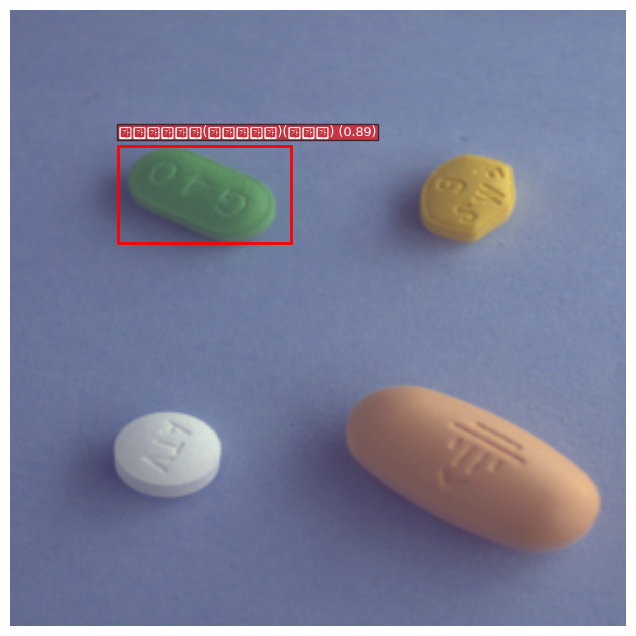

파일명: 1174


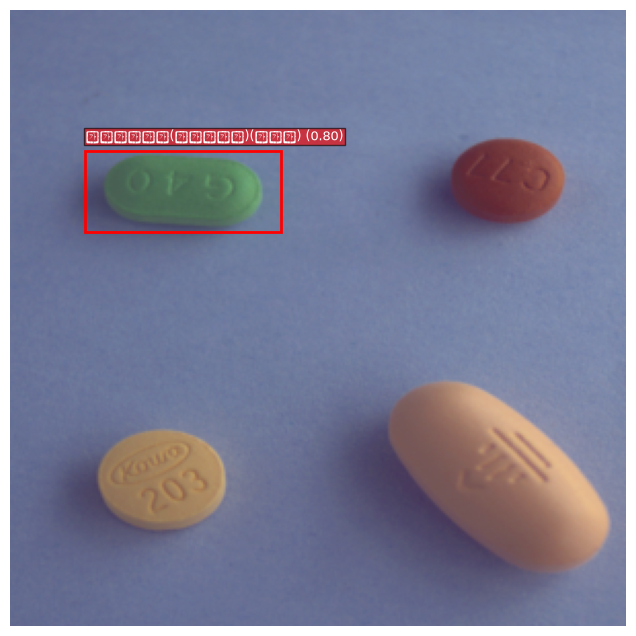

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.25268763..1.0000002].


파일명: 1029


c:\Users\yiydg\Desktop\Vault_home\💼 Projects(Work)\Sprint AI_14기\workspace\프로젝트_초급\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yiydg\Desktop\Vault_home\💼 Projects(Work)\Sprint AI_14기\workspace\프로젝트_초급\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 50577 (\N{HANGUL SYLLABLE YANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yiydg\Desktop\Vault_home\💼 Projects(Work)\Sprint AI_14기\workspace\프로젝트_초급\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 54616 (\N{HANGUL SYLLABLE HA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yiydg\Desktop\Vault_home\💼 Projects(Work)\Sprint AI_14기\workspace\프로젝트_초급\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from fo

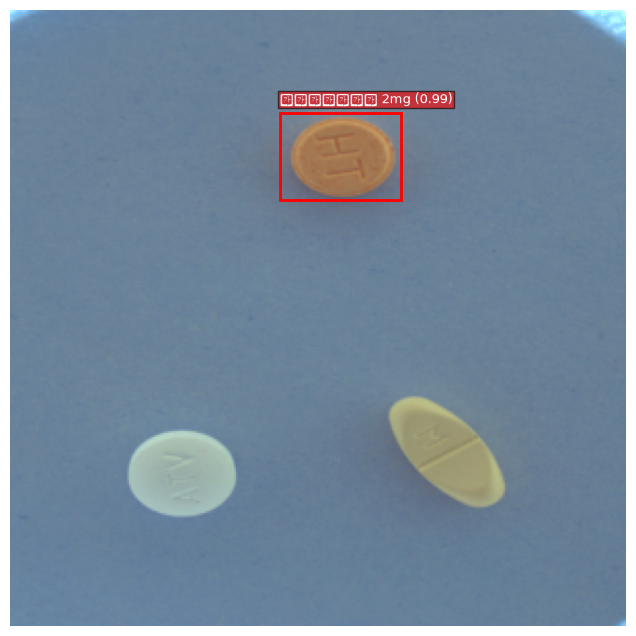

파일명: 875


c:\Users\yiydg\Desktop\Vault_home\💼 Projects(Work)\Sprint AI_14기\workspace\프로젝트_초급\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yiydg\Desktop\Vault_home\💼 Projects(Work)\Sprint AI_14기\workspace\프로젝트_초급\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


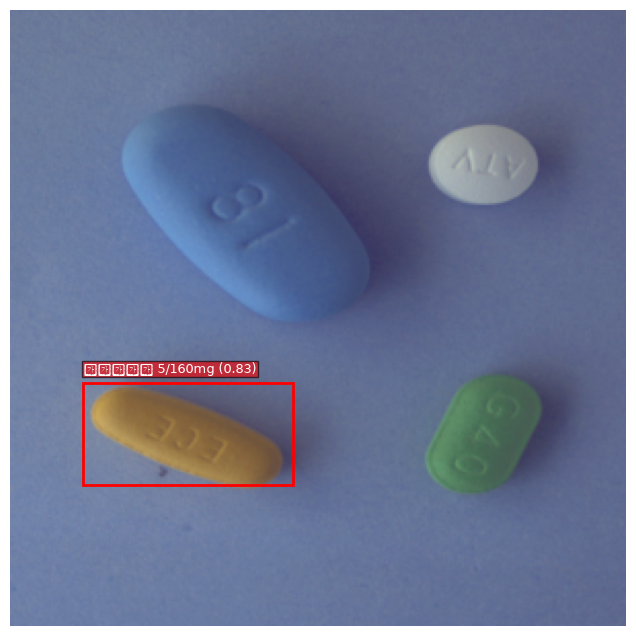

Test Inference:  20%|██        | 1/5 [00:01<00:04,  1.04s/it]

파일명: 1449


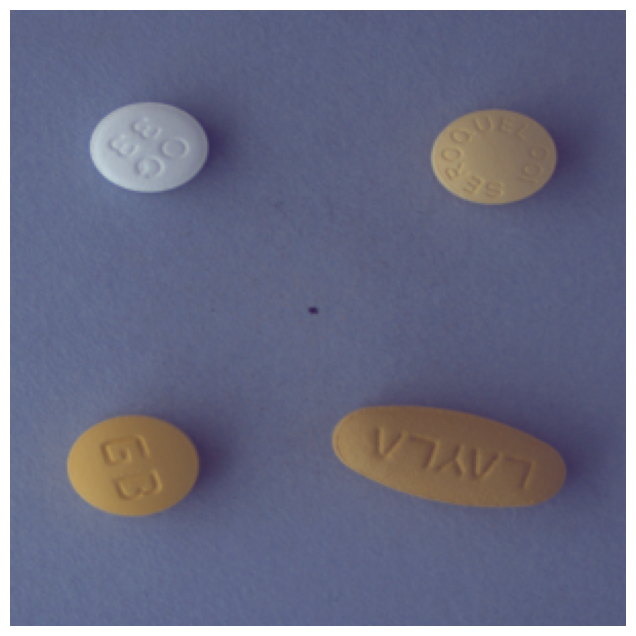

파일명: 1393


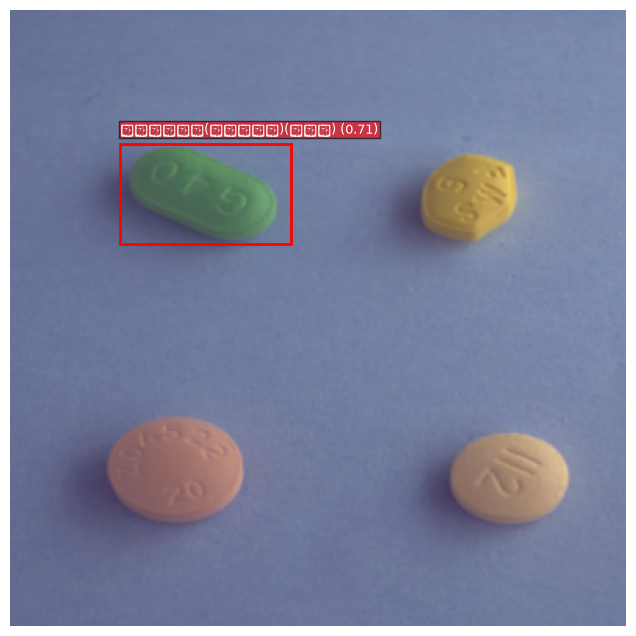

파일명: 1358


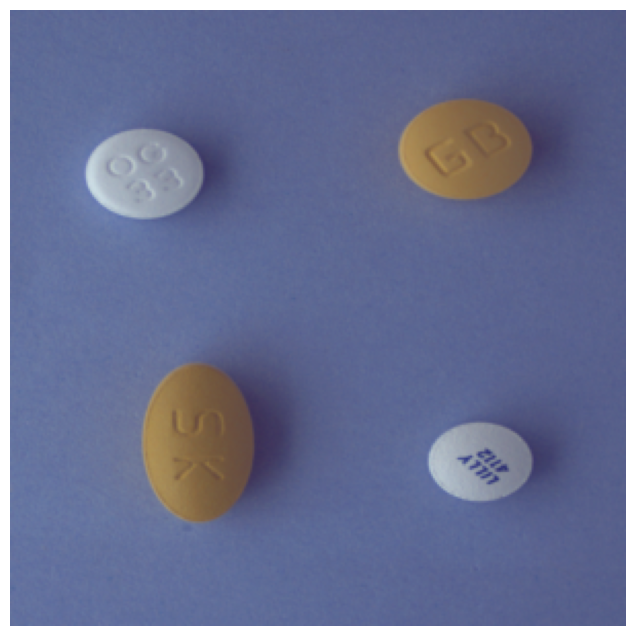

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.1665149..1.0000002].


파일명: 1214


c:\Users\yiydg\Desktop\Vault_home\💼 Projects(Work)\Sprint AI_14기\workspace\프로젝트_초급\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 50500 (\N{HANGUL SYLLABLE A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yiydg\Desktop\Vault_home\💼 Projects(Work)\Sprint AI_14기\workspace\프로젝트_초급\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 53664 (\N{HANGUL SYLLABLE TO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yiydg\Desktop\Vault_home\💼 Projects(Work)\Sprint AI_14기\workspace\프로젝트_초급\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 51247 (\N{HANGUL SYLLABLE JES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


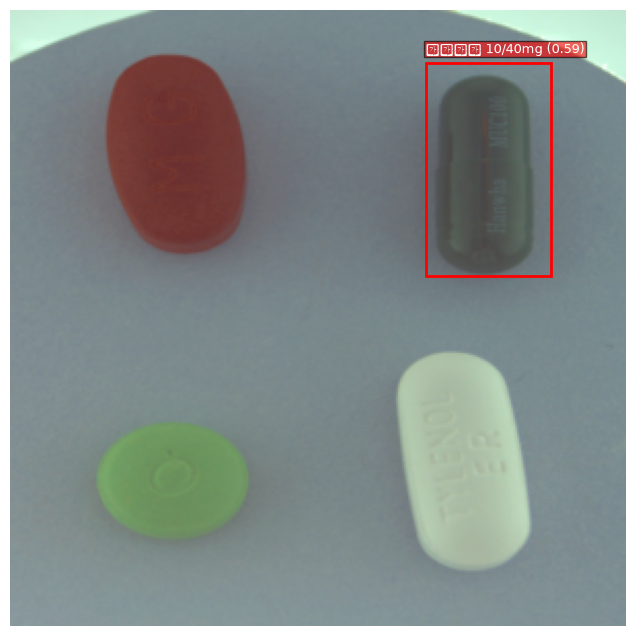

Test Inference:  40%|████      | 2/5 [00:02<00:03,  1.01s/it]

파일명: 868


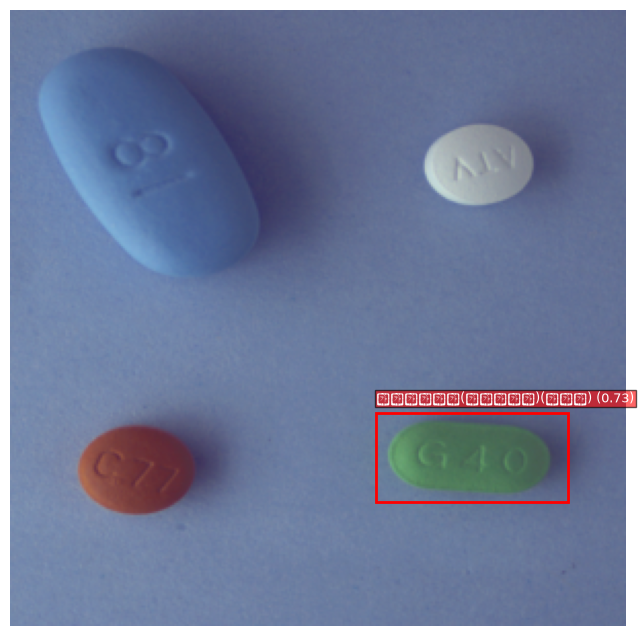

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.23945346..1.0000002].


파일명: 1159


c:\Users\yiydg\Desktop\Vault_home\💼 Projects(Work)\Sprint AI_14기\workspace\프로젝트_초급\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yiydg\Desktop\Vault_home\💼 Projects(Work)\Sprint AI_14기\workspace\프로젝트_초급\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 44540 (\N{HANGUL SYLLABLE GEUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yiydg\Desktop\Vault_home\💼 Projects(Work)\Sprint AI_14기\workspace\프로젝트_초급\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 45817 (\N{HANGUL SYLLABLE DANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yiydg\Desktop\Vault_home\💼 Projects(Work)\Sprint AI_14기\workspace\프로젝트_초급\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 44544 (\N{HANGUL SYLLABLE GEUL}) missing 

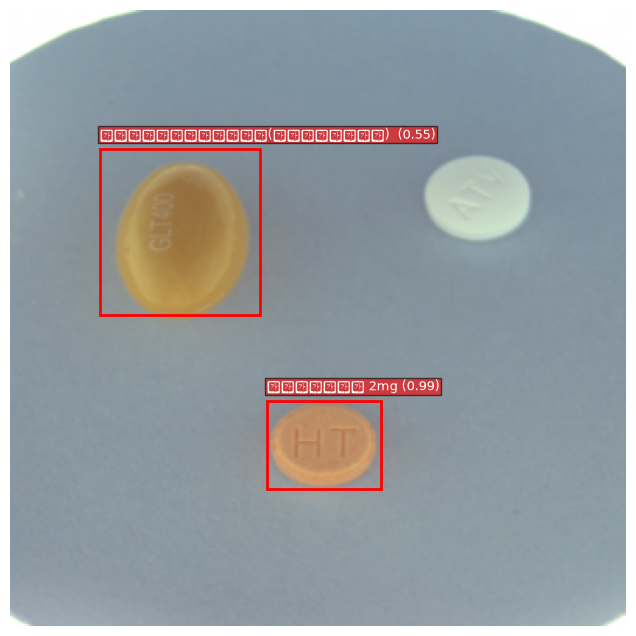

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.25983796..1.0000002].


파일명: 742


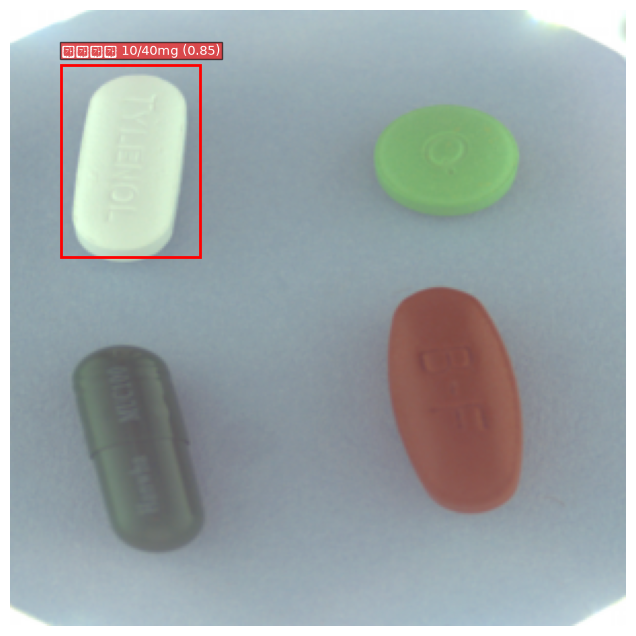

파일명: 874


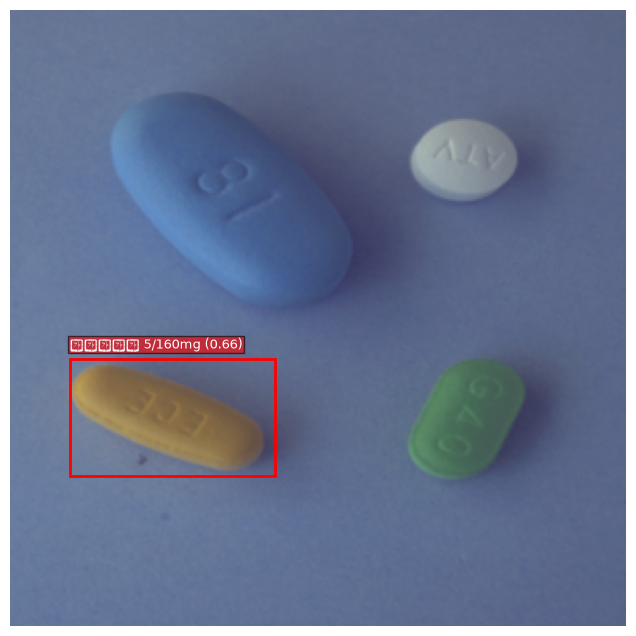

Test Inference:  60%|██████    | 3/5 [00:02<00:01,  1.01it/s]

파일명: 546


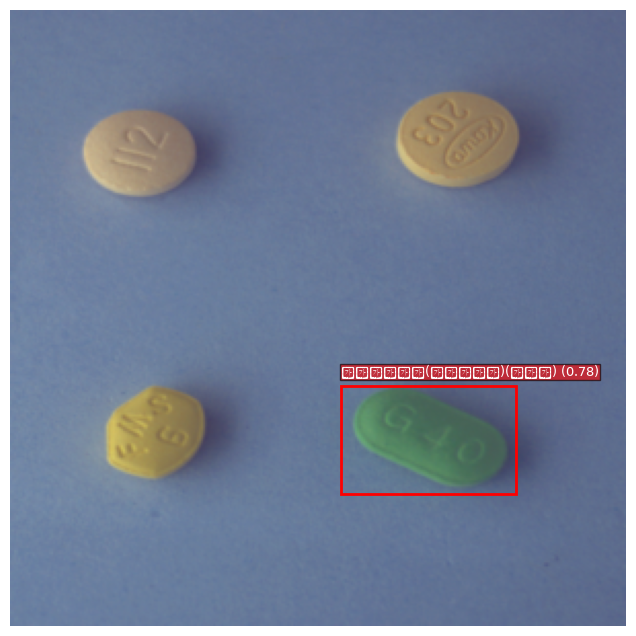

파일명: 1140


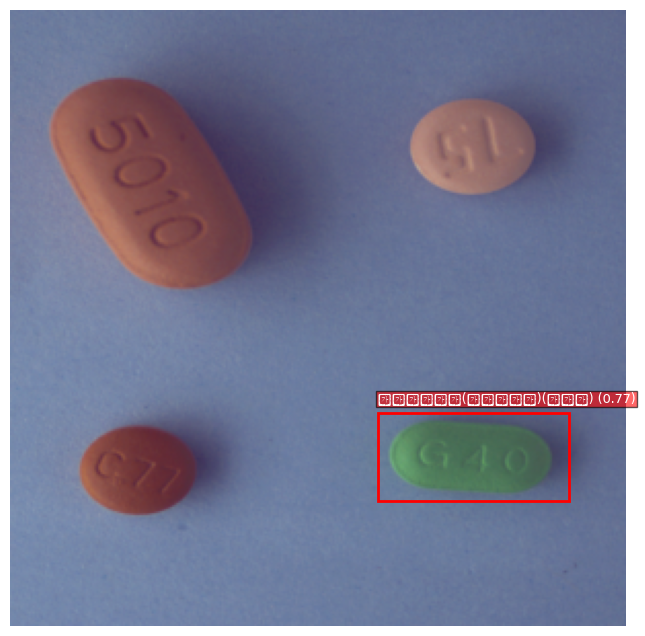

파일명: 612


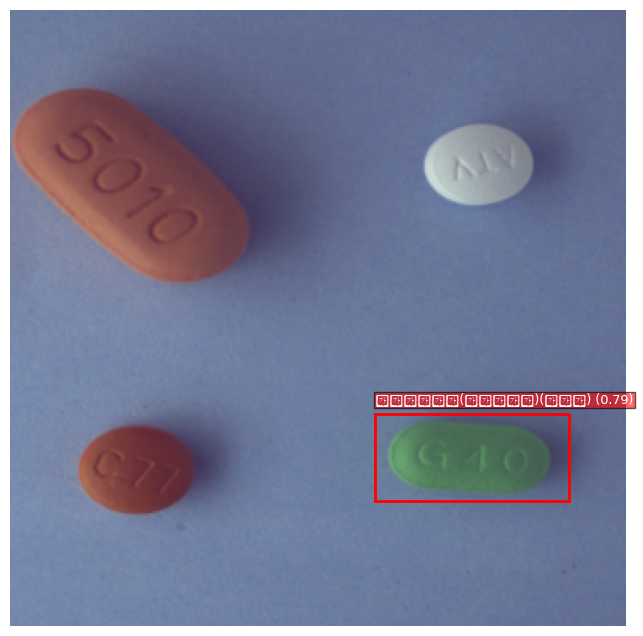

파일명: 346


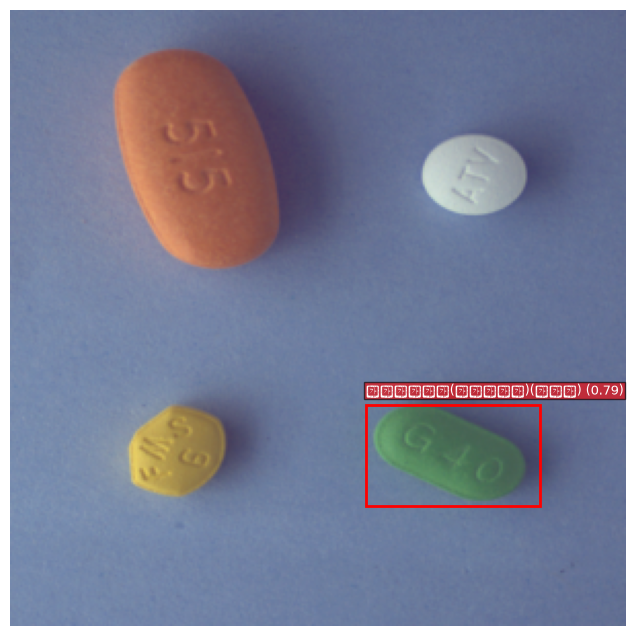

Test Inference:  80%|████████  | 4/5 [00:03<00:00,  1.01it/s]Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.17326427..1.0000002].


파일명: 1044


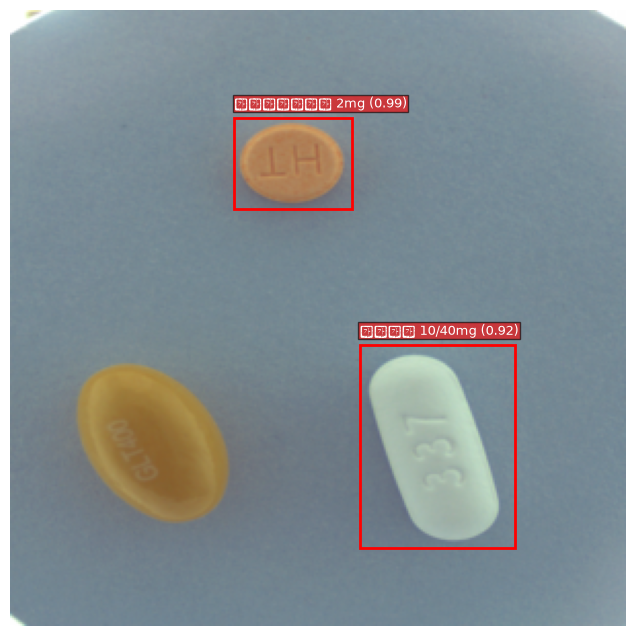

파일명: 1041


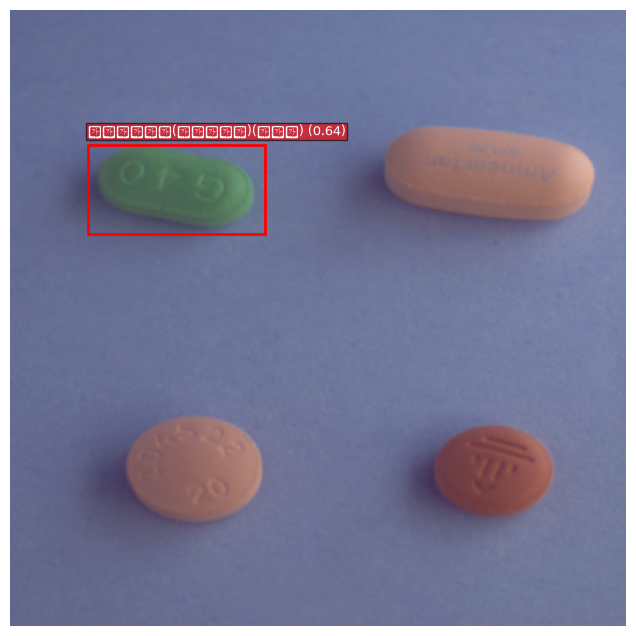

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2416158..1.0000002].


파일명: 1149


c:\Users\yiydg\Desktop\Vault_home\💼 Projects(Work)\Sprint AI_14기\workspace\프로젝트_초급\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 52852 (\N{HANGUL SYLLABLE KA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yiydg\Desktop\Vault_home\💼 Projects(Work)\Sprint AI_14기\workspace\프로젝트_초급\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 48156 (\N{HANGUL SYLLABLE BAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


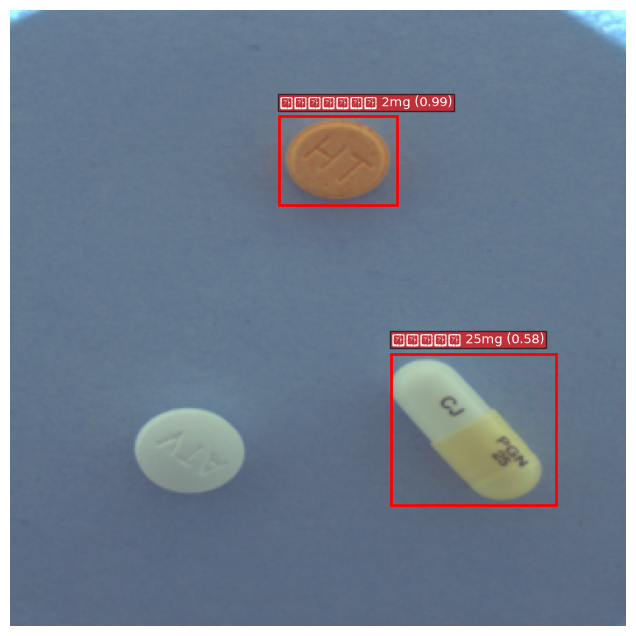

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.24419521..1.0000002].


파일명: 1350


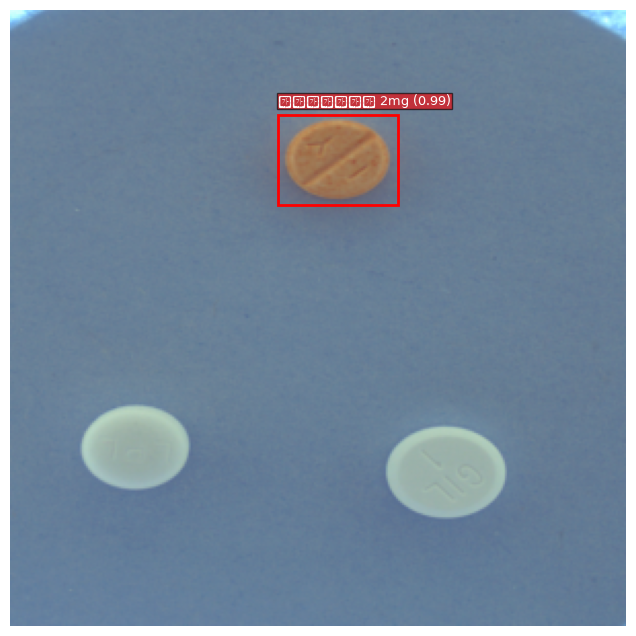

Test Inference: 100%|██████████| 5/5 [00:05<00:00,  1.00s/it]


In [40]:
#@title Test 이미지 20장 추론 및 시각화
model.eval()

with torch.no_grad():
    for images, stems, orig_ws, orig_hs in tqdm(test_loader, desc="Test Inference"):
        images = [img.to(device) for img in images]
        predictions = model(images)

        for img, pred, stem in zip(images, predictions, stems):
            print(f"파일명: {stem}")
            visualize_prediction(img.cpu(), pred, classes)

In [41]:
#@title Submission CSV 생성 (스케일 보정 포함)
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
model.to(device)
model.eval()

all_test_paths = glob.glob(os.path.join(path, "test_images", "*.png"))
all_test_stems = [os.path.splitext(os.path.basename(p))[0] for p in all_test_paths]

submission_test_dataset = TestDataset(
    image_dir=os.path.join(path, "test_images"),
    stems=all_test_stems,
    transforms=val_test_transformer
)
submission_test_loader = DataLoader(
    submission_test_dataset, batch_size=8, shuffle=False,
    collate_fn=lambda x: tuple(zip(*x))
)

def extract_image_id(stem):
    return int(stem)

rows = []
annotation_id = 1
score_thresh = 0.2

RESIZE_TARGET = 300  # v2.Resize((300, 300))과 반드시 일치시킬 것

with torch.no_grad():
    for images, stems, orig_ws, orig_hs in tqdm(submission_test_loader, desc="Submission Inference"):
        images = [img.to(device) for img in images]
        predictions = model(images)

        for pred, stem, orig_w, orig_h in zip(predictions, stems, orig_ws, orig_hs):
            image_id = extract_image_id(stem)
            boxes = pred["boxes"].cpu()
            labels = pred["labels"].cpu()
            scores = pred["scores"].cpu()

            scale_x = orig_w / RESIZE_TARGET
            scale_y = orig_h / RESIZE_TARGET

            for box, label, score in zip(boxes, labels, scores):
                if score.item() < score_thresh:
                    continue

                x_min, y_min, x_max, y_max = box.tolist()

                # 300x300 좌표계 -> 원본 이미지 좌표계로 스케일 복원
                x_min *= scale_x
                x_max *= scale_x
                y_min *= scale_y
                y_max *= scale_y

                bbox_w = x_max - x_min
                bbox_h = y_max - y_min

                category_id = label_to_category[label.item()]

                rows.append([
                    annotation_id, image_id, category_id,
                    round(x_min, 2), round(y_min, 2),
                    round(bbox_w, 2), round(bbox_h, 2),
                    round(score.item(), 4)
                ])
                annotation_id += 1

with open("submission.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["annotation_id", "image_id", "category_id", "bbox_x", "bbox_y", "bbox_w", "bbox_h", "score"])
    writer.writerows(rows)

print(f"총 {len(rows)}개 예측 저장 완료")

Submission Inference: 100%|██████████| 106/106 [00:57<00:00,  1.83it/s]

총 3101개 예측 저장 완료


In [42]:
#@title label_to_category 매핑 자체 검증
expected_labels = set(range(1, num_classes))  # background(0) 제외
mapped_labels = set(label_to_category.keys())

print(f"모델이 출력 가능한 라벨 범위: {expected_labels}")
print(f"label_to_category에 존재하는 라벨: {mapped_labels}")
print(f"매핑 누락된 라벨: {expected_labels - mapped_labels}")
print(f"매핑 결과 category_id 샘플 5개: {list(label_to_category.items())[:5]}")

모델이 출력 가능한 라벨 범위: {1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56}
label_to_category에 존재하는 라벨: {1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56}
매핑 누락된 라벨: set()
매핑 결과 category_id 샘플 5개: [(1, 1900), (2, 2483), (3, 3351), (4, 3483), (5, 3544)]
